# Micrograd

## Example usage

!pip3 install micrograd

In [2]:
from micrograd.engine import Value

a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f
print(f'{g.data:.4f}') # prints 24.7041, the outcome of this forward pass
g.backward()
print(f'{a.grad:.4f}') # prints 138.8338, i.e. the numerical value of dg/da
print(f'{b.grad:.4f}') # prints 645.5773, i.e. the numerical value of dg/db

24.7041
138.8338
645.5773


## Nueral Networks

Nueral networks are just mathematical expressions. They take the input data as an input and the weights of a nueral network as an input. The output is the predictions of the nueral net or the loss function. 

Nueral networks are just a certin class of mathamatical expressions. 

## Derivatives

In [9]:
!pip3 install numpy
!pip3 install matplotlib

  Using cached matplotlib-3.11.2-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (125 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
Using cached matplotlib-3.11.2-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (11.0 MB)
Using cached contourpy-1.4.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (384 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.65.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.3 MB)
Using cached kiwisolver-1.5.1-cp314-cp314-

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 3*x**2 - 4*x + 5

f(3.0)

20.0

xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

What is the derivative of this function at every point on the x?

**Derivative defenition**

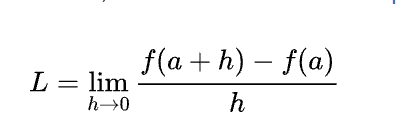

This equation states that if we slightly bump up a by a vlaue h how would the function respond. With what type of sensativity will it respond, what is the slope at that point. Does the function go up or does it go down and by how much. This is the slope of the function

In [23]:
h = 0.001
x = 3.0
f(x + h)

20.014003000000002

**f(x + h)** - tells us the y after the addition of h 

In [17]:
f(x + h) - f(x)

0.01400300000000243

**f(x + h) - f(x)** - tells us by how much the increase/decrease was

In [20]:
(f(x + h) - f(x))/h

14.00300000000243

**(f(x + h) - f(x))/h** - this is the slope at that point

### Going more complex

In [34]:
a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


We want to see now the derivatives of d with respect to a, b and c

In [35]:
h = 0.0001

d1 = a * b + c

Lets see the derivative of d with respect to a

In [36]:
a += h
d2 = a * b + c 

print("d1:", d1)
print("d2:", d2)
print("Slope:", (d2 - d1)/h)

d1: 4.0
d2: 3.999699999999999
Slope: -3.000000000010772


Now lets see the influence of b on the equation

In [37]:
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
b += h
d2 = a * b + c 

print("d1:", d1)
print("d2:", d2)
print("Slope:", (d2 - d1)/h)

d1: 4.0
d2: 4.0002
Slope: 2.0000000000042206


Now lets see the influence of c on the equation

In [39]:
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
c += h
d2 = a * b + c 

print("d1:", d1)
print("d2:", d2)
print("Slope:", (d2 - d1)/h)

d1: 4.0
d2: 4.0001
Slope: 0.9999999999976694


## Nueral Network - (continue)

The blow class gives us the full history of how we got a certin value

In [19]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()
    
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [76]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [77]:
d._op

'+'

Now we want to be able to visulaize the dependency graph. Namely, how we got to a certin result

In [60]:
!pip3 install graphviz

In [7]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

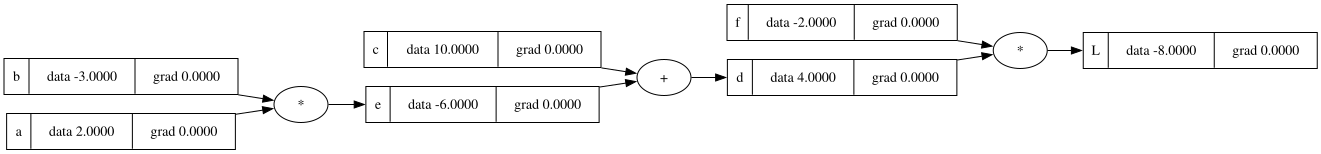

In [11]:
draw_dot(L)

**What has been done so far**

We are able to build out mathamatical expressions using only plus, minus and multiply. They are scalar valued along the way and we can do a forward pass and build out a mathamatical expression that produces and output L.

The graph above visulaizes the forward pass. 

**Next Steps**

We would like to run back propogation. We would start from the end (L in the above case) and reverse and calculate the gradient along all of the intermidiate values. Basically, we will calulate the derivative of each of the values with respect to L. 
Ex:
whats the derivative of L with respect to L
whats the derivative of e with respect to L
whats the derivative of f with respect to L
whats the derivative of c with respect to L
...

**Important**: think of the data part from the above graph as the weights of the nueral network

**Lets start doing diffrantiation**

We know that L = d * f

We want to knwo what is dL/dd = ? -> f

The defenition of a derrivative is (f(x+h)-f(x))/h -> ((d + h) * f - d * f)/h ->(df * hd - df)/h -> hf/h -> f

What does this mean, this mean that if we change d abit then L will change by f 


**Lets get deeper into it**

We know how L is sensative to d however we want to know how is L sensative to e. Namely, how does c impact L through d. 

We want to find dL/dc and dL/de

How do we find dL/dc? How is L sensative to c? 

We know dL/dd and we also know how c imapcts d (use the same method as we used above). Meaning if we know the impact that c is having on d and the impace that d is having on L we can derieve the impace that c is having on L.

Lets find dd/dc.

d = c + e -> dd/dc = 1

Lets find dd/de.

d = c + e -> dd/de = 1

Now we fully know how d impacts L and how c and e impacts d. Now we need to put this information together to find out how c and e impact L. The answer is the **chain rule**.

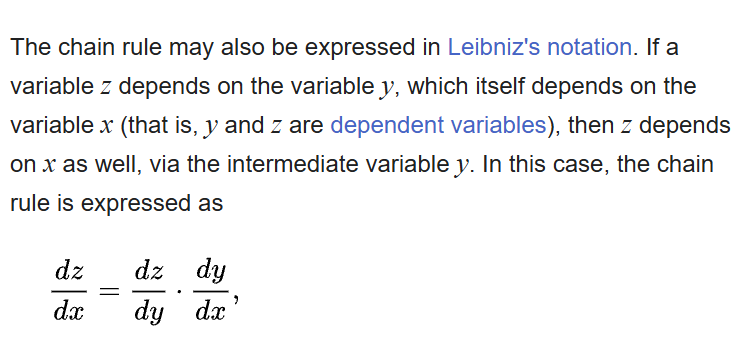

**Want**: dL/dc = (dL / dd) * (dd / dc)

**Know**: dL/dd and dd/dc

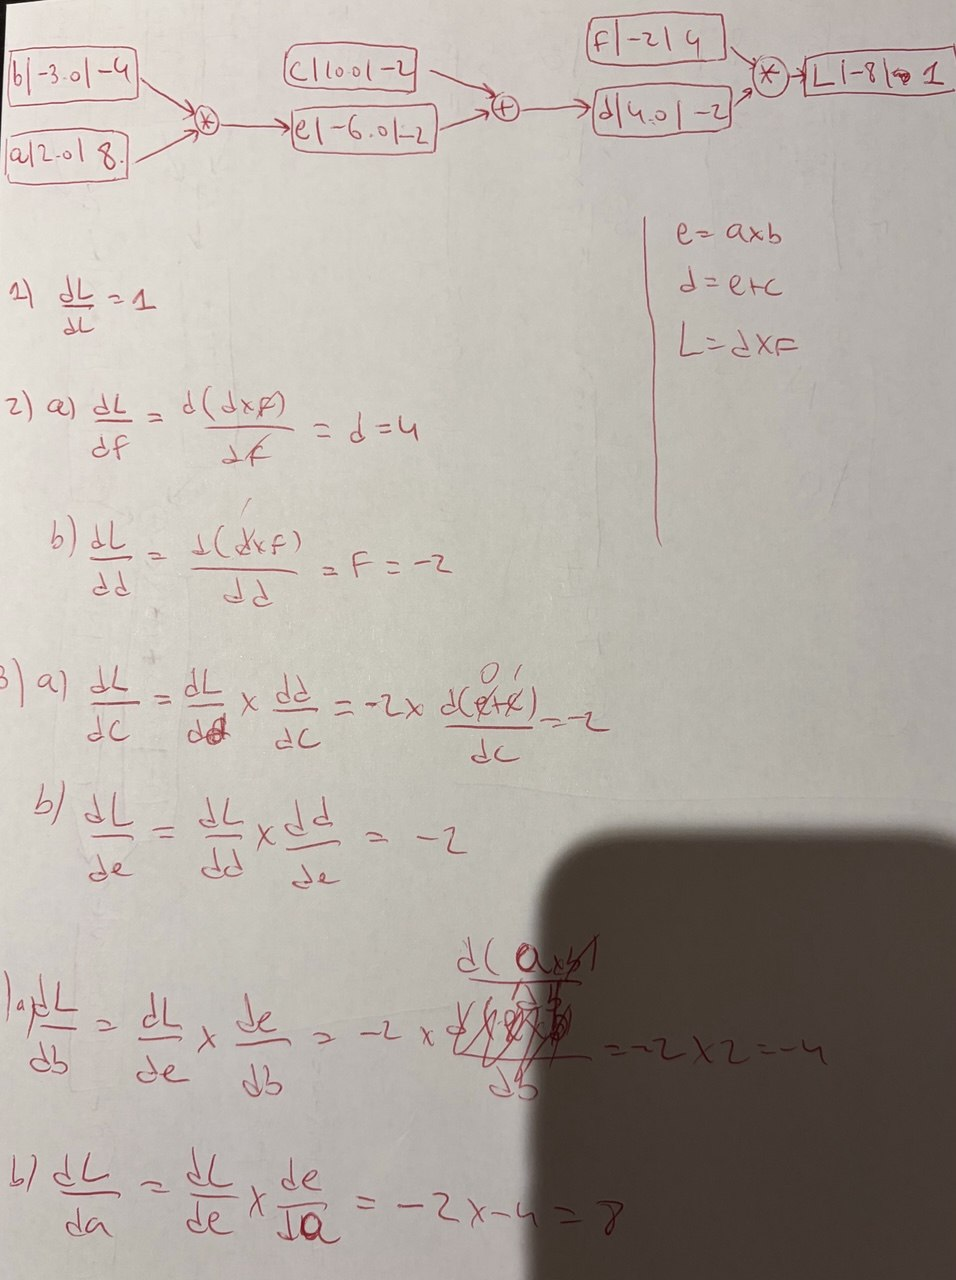

**Now lets get the deepest**

Now we want to find dL/da. 

Using the chain rule this will be:

dL/da = (dL/de) * (de/da)

### Nueron disucssion

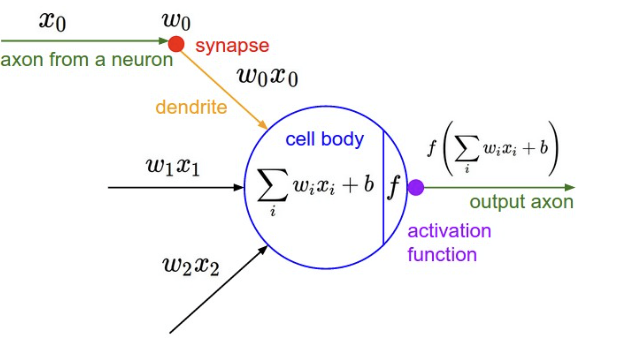

**Activation Function**- usualy a squashing function like a sigmoid or tanh

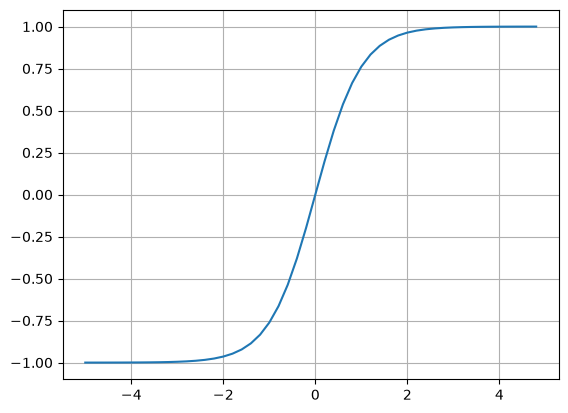

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

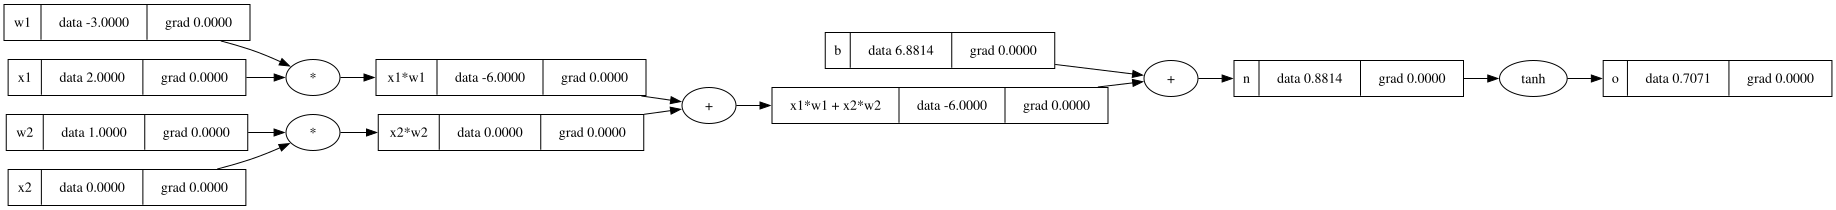

In [11]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

The above code describes how a nueron get created. For nueral networks we care mostly about the **W1** and **W2** as these are the parametrs that we will be chanching

**Manual back propogation**: 

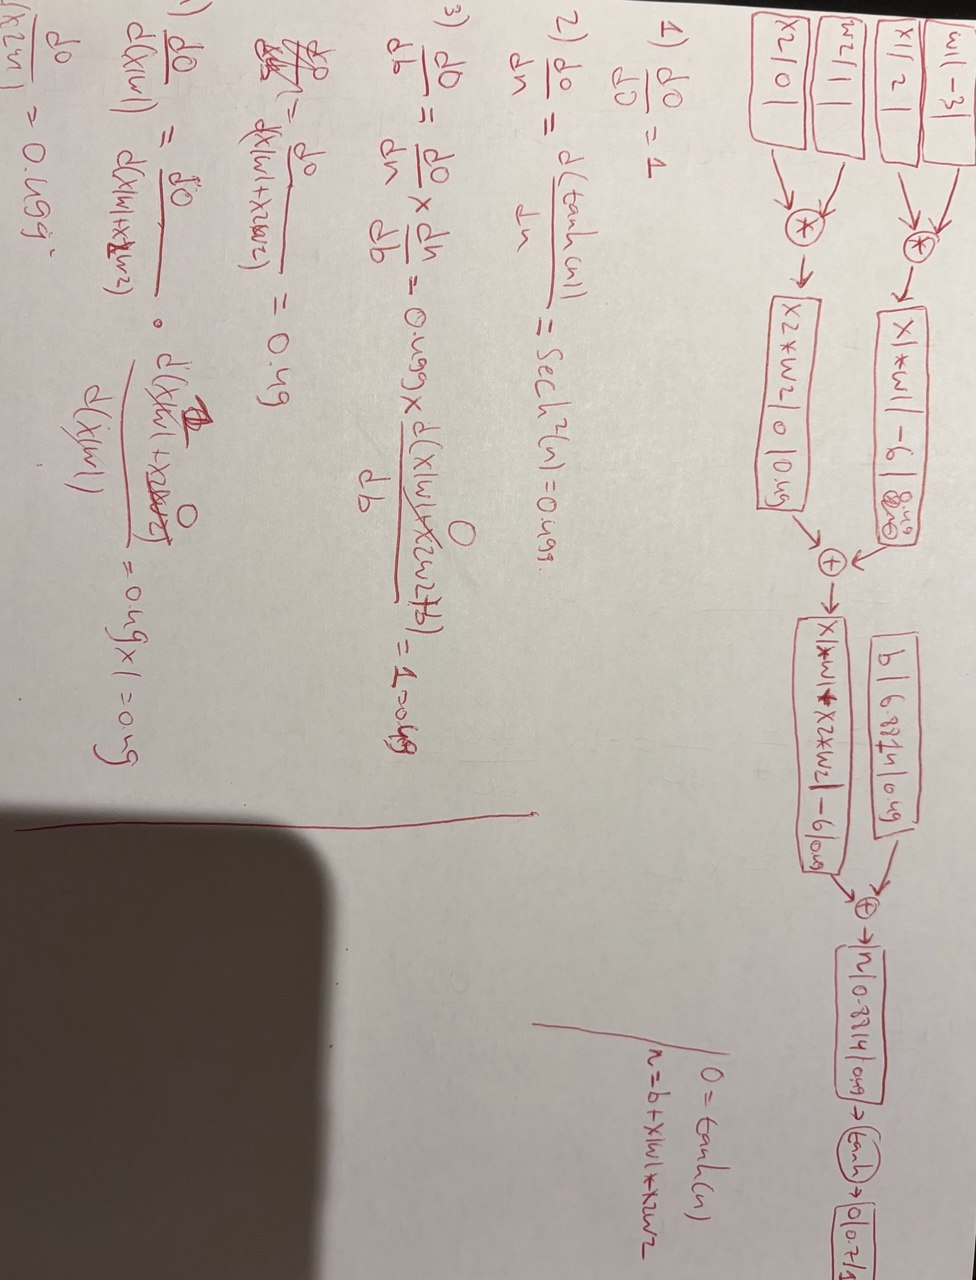 

**Testing built out back propogation**

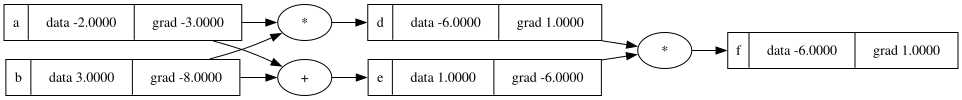

In [20]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)

## Implementing the same thing in Pytorch

In [22]:
!pip3 install torch

  Using cached torch-2.14.0-cp314-cp314-manylinux_2_28_x86_64.whl.metadata (37 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached cuda_toolkit-13.0.3.0-py2.py3-none-any.whl.metadata (17 kB)
  Using cached nvidia_cudnn_cu13-9.24.0.43-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.1-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.30.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached triton-3.8.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (978 bytes)
  Using cached nvidia_cublas-13.1.1.3-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cuda_nvrtc-13.0.88-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)

In [32]:
import torch

x1 = torch.Tensor([2.0]).double()
x1.requires_grad = True

x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True

w1 = torch.Tensor([-3.0]).double()
w1.requires_grad = True

w2 = torch.Tensor([1.0]).double()
w2.requires_grad = True

bias = torch.Tensor([6.8813]).double()
bias.requires_grad = True

n = x1*w1 + x2+w2 + bias
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.9546075955221163
---
x2 0.08872433857148367
w2 0.08872433857148367
x1 -0.266173015714451
w1 0.17744867714296733
